In [1]:
!pip install pandas
!pip install nltk
!pip install scikit-learn
!pip install PyPDF2

In [2]:
import os
import re
import pandas as pd
import nltk

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from PyPDF2 import PdfReader

In [3]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\deepa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\deepa\OneDrive\Desktop\AI_Resume_Screening
['.ipynb_checkpoints', 'jd.txt', 'output', 'resume.pdf', 'Resume_Screening.ipynb']


In [5]:
job_file = "jd.txt"
resume_file = "resume.pdf"

In [6]:
with open(job_file, "r", encoding="utf-8") as file:
    job_description = file.read()

print(job_description)

Job Title: Python AI Developer

Company: ABC Technologies

Required Skills:
Python
Machine Learning
SQL
Pandas
NumPy
Scikit-learn
Data Analysis
Communication Skills
Problem Solving

Experience:
0-2 Years

Education:
B.Tech in Computer Science / AI & ML / IT

Responsibilities:
- Build Machine Learning models
- Data preprocessing
- Work with datasets
- Develop AI applications
- Collaborate with team members
2.Job Title: AI/ML Engineer

Company: TechNova Solutions Pvt. Ltd.

Location: Hyderabad, India

Job Type: Full-Time

Job Description:

We are looking for a passionate AI/ML Engineer to join our development team. The ideal candidate should have knowledge of Python, Machine Learning, Data Analysis, and Artificial Intelligence concepts. The candidate will work on developing intelligent applications, data preprocessing, model building, and performance evaluation.

Required Skills:
- Python
- Machine Learning
- Deep Learning
- Data Analysis
- Pandas
- NumPy
- Scikit-learn
- SQL
- Git
- Pro

In [7]:
pdf = PdfReader(resume_file)

resume_text = ""

for page in pdf.pages:

    text = page.extract_text()

    if text:
        resume_text += text

print(resume_text)

Resume 1 – Rahul Sharma  
• B.Tech CSE (2026)  
• Skills: Python, Java, SQL, Machine Learning, HTML, CSS  
• Projects:  
o Student Management System  
o House Price Prediction  
• Internship: Python Developer Intern (2 months)  
• Certifications:  
o Python for Data Science  
o Machine Learning Basics  
Resume 2 – Priya Reddy  
• B.Tech AI & DS (2026)  
• Skills: Python, Pandas, NumPy, Power BI, Excel, SQL  
• Projects:  
o Sales Dashboard  
o Customer Churn Prediction  
• Internship: Data Analyst Intern  
• Certifications:  
o Google Data Analytics  
o SQL Intermediate  
Resume 3 – Arjun Kumar  
• B.Tech IT (2026)  
• Skills: Java, Spring Boot, MySQL, Git, REST API  
• Projects:  
o Online Banking System  
o Employee Management Portal  
• Internship: Java Full Stack Intern  
• Certifications:  o Java Programming  
o Git & GitHub  
Resume 4 – Sneha Patel  
• B.Tech AIML (2026)  
• Skills: Python, TensorFlow, OpenCV, Deep Learning, NLP  
• Projects:  
o Face Mask Detection  
o Resume Sc

In [11]:
import re

resume_list = re.split(r"Resume\s+\d+\s+[–-]\s+", resume_text)

resume_list = [r.strip() for r in resume_list if r.strip()]

print("Total Resumes:", len(resume_list))

Total Resumes: 4


In [12]:
import re

resume_list = re.split(r"Resume\s+\d+\s+[–-]\s+", resume_text)

resume_list = [r.strip() for r in resume_list if r.strip()]

print("Total Resumes:", len(resume_list))

Total Resumes: 4


In [13]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z ]', ' ', text)

    words = text.split()

    stop_words = set(stopwords.words("english"))

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [14]:
job_description = clean_text(job_description)

clean_resumes = []

for resume in resume_list:
    clean_resumes.append(clean_text(resume))

print(clean_resumes[0])

rahul sharma b tech cse skills python java sql machine learning html css projects student management system house price prediction internship python developer intern months certifications python data science machine learning basics


In [15]:
documents = [job_description] + clean_resumes

vectorizer = TfidfVectorizer()

vectors = vectorizer.fit_transform(documents)

In [16]:
scores = cosine_similarity(vectors[0:1], vectors[1:]).flatten()

print(scores)

[0.29397471 0.20540441 0.03764364 0.20007617]


In [17]:
candidate_names = [
    "Rahul Sharma",
    "Priya Reddy",
    "Arjun Kumar",
    "Sneha Patel"
]

In [29]:
result = pd.DataFrame({
    "Candidate Name": candidate_names,
    "Similarity Score": scores
})

result = result.sort_values(
    by="Similarity Score",
    ascending=False
)

result["Rank"] = range(1, len(result) + 1)

result["Match %"] = (result["Similarity Score"] * 100).round(2)

print(result)

  Candidate Name  Similarity Score  Rank  Match %
0   Rahul Sharma          0.293975     1    29.40
1    Priya Reddy          0.205404     2    20.54
3    Sneha Patel          0.200076     3    20.01
2    Arjun Kumar          0.037644     4     3.76


In [31]:
# Sort based on similarity score
result = result.sort_values(
    by="Similarity Score",
    ascending=False
)

# Add Rank
result["Rank"] = range(1, len(result) + 1)

# Normalize Match Percentage
result["Match %"] = (
    result["Similarity Score"] /
    result["Similarity Score"].max() * 100
).round(2)

# Round similarity score
result["Similarity Score"] = result["Similarity Score"].round(3)

# Status based on Rank
def get_status(rank):
    if rank == 1:
        return "Selected"
    elif rank == 2:
        return "Shortlisted"
    elif rank == 3:
        return "Consider"
    else:
        return "Rejected"

result["Status"] = result["Rank"].apply(get_status)

# Rearrange columns
result = result[
    [
        "Rank",
        "Candidate Name",
        "Similarity Score",
        "Match %",
        "Status"
    ]
]

print(result)

# Save output
result.to_csv("output/candidate_ranking.csv", index=False)

   Rank Candidate Name  Similarity Score  Match %       Status
0     1   Rahul Sharma             0.294   100.00     Selected
1     2    Priya Reddy             0.205    69.87  Shortlisted
3     3    Sneha Patel             0.200    68.06     Consider
2     4    Arjun Kumar             0.038    12.81     Rejected


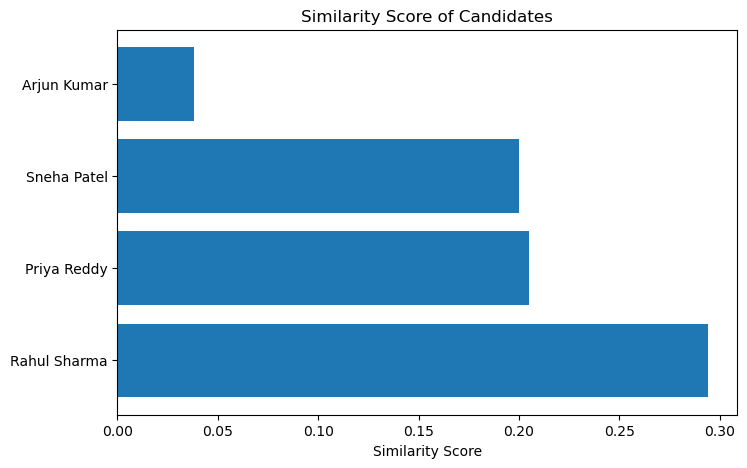

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.barh(result["Candidate Name"], result["Similarity Score"])

plt.title("Similarity Score of Candidates")

plt.xlabel("Similarity Score")

plt.show()

In [33]:
result.to_csv("output/candidate_ranking.csv", index=False)

print("Candidate ranking saved successfully!")

Candidate ranking saved successfully!
